In [1]:
import pandas as pd
import numpy as np
import time
import warnings
import joblib
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint, LearningRateScheduler)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

In [2]:
print("="*55)
print("  LOADING DATA")
print("="*55)

df = pd.read_csv('features_day2.csv', index_col='DateTime', parse_dates=True)
feature_cols = [c for c in df.columns if c != 'outage']
X_raw = df[feature_cols].copy()
y_raw = df['outage'].copy()

print(f"\n  Raw shape    : {X_raw.shape}")
print(f"  Outage rate  : {y_raw.mean()*100:.3f}%")
print(f"  Features     : {len(feature_cols)}")
print(f"\n  Raw feature list:")
for i, col in enumerate(feature_cols, 1):
    print(f"    {i:02d}. {col}")

  LOADING DATA

  Raw shape    : (52416, 30)
  Outage rate  : 0.727%
  Features     : 30

  Raw feature list:
    01. zone1
    02. zone2
    03. zone3
    04. temp
    05. humidity
    06. wind_speed
    07. hour
    08. dayofweek
    09. month
    10. is_weekend
    11. is_night
    12. z1_rolling_mean_w12
    13. z1_rolling_std_w12
    14. z1_rolling_min_w12
    15. z1_rolling_max_w12
    16. z1_rolling_mean_w144
    17. z1_rolling_std_w144
    18. z1_rolling_min_w144
    19. z1_rolling_max_w144
    20. z1_rolling_mean_w288
    21. z1_rolling_std_w288
    22. z1_rolling_min_w288
    23. z1_rolling_max_w288
    24. z1_diff_1
    25. z1_diff_6
    26. z1_diff_144
    27. z1_lag_1
    28. z1_lag_6
    29. z1_lag_144
    30. z1_zscore


In [3]:
print("\n" + "█"*55)
print("  PHASE 1 — DATA HARDENING (SAFE VERSION)")
print("█"*55)

np.random.seed(42)
X_hard = X_raw.copy()
y_hard = y_raw.copy()   # ← DO NOT touch labels

# ── Step 1: Very light Gaussian noise (0.5% not 2%) ────────
print("\n  STEP 1/3 — Light Gaussian noise (0.5% of std)")
print("            Just enough to prevent overfitting")
t0 = time.time()
for col in feature_cols:
    std   = X_hard[col].std()
    noise = np.random.normal(0, 0.005 * std, size=len(X_hard))
    X_hard[col] = X_hard[col] + noise
print(f"            Done in {time.time()-t0:.1f}s ✅")

# ── Step 2: Add meaningful interaction features ─────────────
print("\n  STEP 2/3 — Adding interaction features")
t0 = time.time()

X_hard['z1_z2_ratio']      = X_hard['zone1'] / (X_hard['zone2'] + 1e-6)
X_hard['z1_z3_ratio']      = X_hard['zone1'] / (X_hard['zone3'] + 1e-6)
X_hard['all_zones_sum']    = X_hard['zone1'] + X_hard['zone2'] + X_hard['zone3']
X_hard['zone_std']         = X_hard[['zone1','zone2','zone3']].std(axis=1)
X_hard['temp_x_hour']      = X_hard['temp'] * X_hard['hour']
X_hard['wind_x_z1']        = X_hard['wind_speed'] * X_hard['zone1']
X_hard['humidity_x_z1']    = X_hard['humidity'] * X_hard['zone1']
X_hard['volatility_ratio'] = (
    X_hard['z1_rolling_std_w12'] /
    (X_hard['z1_rolling_std_w144'] + 1e-6)
)
X_hard['zscore_momentum']  = X_hard['z1_zscore'].diff(6).fillna(0)

new_features = ['z1_z2_ratio','z1_z3_ratio','all_zones_sum','zone_std',
                'temp_x_hour','wind_x_z1','humidity_x_z1',
                'volatility_ratio','zscore_momentum']

print(f"            Added {len(new_features)} features")
print(f"            Done in {time.time()-t0:.1f}s ✅")

# ── Step 3: Clip outliers created by interaction terms ──────
print("\n  STEP 3/3 — Clipping extreme outliers in new features")
t0 = time.time()
for col in new_features:
    p1 = X_hard[col].quantile(0.01)
    p99 = X_hard[col].quantile(0.99)
    X_hard[col] = X_hard[col].clip(p1, p99)
print(f"            Done in {time.time()-t0:.1f}s ✅")

# ── No label flipping, no corruption ───────────────────────
all_feature_cols = list(X_hard.columns)

print(f"\n  PHASE 1 COMPLETE ✅")
print(f"  Original features  : {len(feature_cols)}")
print(f"  Total features now : {len(all_feature_cols)}")
print(f"  Labels untouched   : {y_hard.sum()} outages preserved")
print(f"\n  ⚠️  Note: NO label flipping, NO feature corruption")
print(f"      Heavy training comes from architecture + CV + epochs")
print(f"      NOT from destroying the training signal")


███████████████████████████████████████████████████████
  PHASE 1 — DATA HARDENING (SAFE VERSION)
███████████████████████████████████████████████████████

  STEP 1/3 — Light Gaussian noise (0.5% of std)
            Just enough to prevent overfitting
            Done in 0.1s ✅

  STEP 2/3 — Adding interaction features
            Added 9 features
            Done in 0.0s ✅

  STEP 3/3 — Clipping extreme outliers in new features
            Done in 0.1s ✅

  PHASE 1 COMPLETE ✅
  Original features  : 30
  Total features now : 39
  Labels untouched   : 381 outages preserved

  ⚠️  Note: NO label flipping, NO feature corruption
      Heavy training comes from architecture + CV + epochs
      NOT from destroying the training signal


In [4]:
print("\n" + "="*55)
print("  SPLIT + BALANCE + SCALE")
print("="*55)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_hard, y_hard, test_size=0.2, random_state=42, stratify=y_hard
)
print(f"\n  Train : {X_train.shape[0]:,} rows")
print(f"  Test  : {X_test.shape[0]:,} rows")

# Fast oversample
X_maj = X_train[y_train == 0]
y_maj = y_train[y_train == 0]
X_min = X_train[y_train == 1]
y_min = y_train[y_train == 1]

print(f"\n  Before balance → Normal: {len(X_maj):,} | Outage: {len(X_min):,}")

X_min_up, y_min_up = resample(
    X_min, y_min,
    replace=True, n_samples=len(X_maj), random_state=42
)
X_train_bal = pd.concat([X_maj, X_min_up]).sample(frac=1, random_state=42).reset_index(drop=True)
y_train_bal = pd.concat([y_maj, y_min_up]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"  After  balance → Normal: {(y_train_bal==0).sum():,} | Outage: {(y_train_bal==1).sum():,}")

# Scale
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, 'scaler_hard.pkl')
print(f"\n  Scaled shape : {X_train_scaled.shape}")
print(f"  scaler_hard.pkl saved ✅")

INPUT_DIM = X_train_scaled.shape[1]
print(f"\n  Input dimension for NN : {INPUT_DIM} features")


  SPLIT + BALANCE + SCALE

  Train : 41,932 rows
  Test  : 10,484 rows

  Before balance → Normal: 41,627 | Outage: 305
  After  balance → Normal: 41,627 | Outage: 41,627

  Scaled shape : (83254, 39)
  scaler_hard.pkl saved ✅

  Input dimension for NN : 39 features


In [5]:
print("\n" + "█"*55)
print("  PHASE 2 — ARCHITECTURE TOURNAMENT")
print("  4 architectures × 5-fold CV = 20 training runs")
print("  Each run prints epoch-by-epoch live")
print("█"*55)

# The 4 competing architectures (small → giant)
ARCHITECTURES = {
    'Arch A — Compact'   : [64, 32],
    'Arch B — Medium'    : [256, 128, 64],
    'Arch C — Large'     : [512, 256, 128, 64],
    'Arch D — Giant'     : [1024, 512, 256, 128, 64, 32],
}

def build_model(layer_sizes, input_dim, learning_rate=0.001, dropout=0.3):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    for i, units in enumerate(layer_sizes):
        model.add(layers.Dense(units,            name=f'Dense_{i+1}'))
        model.add(layers.BatchNormalization(     name=f'BN_{i+1}'))
        model.add(layers.Activation('relu',      name=f'ReLU_{i+1}'))
        # reduce dropout in deeper layers
        drop = dropout * (0.8 ** i)
        if drop > 0.05:
            model.add(layers.Dropout(drop,       name=f'Drop_{i+1}'))

    model.add(layers.Dense(1, activation='sigmoid', name='Output'))

    model.compile(
        optimizer = Adam(learning_rate=learning_rate),
        loss      = 'binary_crossentropy',
        metrics   = [
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ]
    )
    return model

# Print architecture summary for each
print("\n  Architecture overview:")
for name, layers_list in ARCHITECTURES.items():
    m = build_model(layers_list, INPUT_DIM)
    params = m.count_params()
    print(f"\n  {name}")
    print(f"    Layers : {layers_list}")
    print(f"    Params : {params:,}")
    del m

print(f"\n  Ready to tournament. Starting in 3 seconds...")
time.sleep(3)


███████████████████████████████████████████████████████
  PHASE 2 — ARCHITECTURE TOURNAMENT
  4 architectures × 5-fold CV = 20 training runs
  Each run prints epoch-by-epoch live
███████████████████████████████████████████████████████

  Architecture overview:


  Arch A — Compact
    Layers : [64, 32]
    Params : 5,057

  Arch B — Medium
    Layers : [256, 128, 64]
    Params : 53,249

  Arch C — Large
    Layers : [512, 256, 128, 64]
    Params : 196,865

  Arch D — Giant
    Layers : [1024, 512, 256, 128, 64, 32]
    Params : 748,417

  Ready to tournament. Starting in 3 seconds...


In [6]:
class LiveLogger(keras.callbacks.Callback):
    def __init__(self, arch_name, fold, total_folds):
        super().__init__()
        self.arch_name   = arch_name
        self.fold        = fold
        self.total_folds = total_folds
        self.best_val_loss = np.inf
        self.best_epoch    = 0

    def on_train_begin(self, logs=None):
        self.start = time.time()
        print(f"\n  {'─'*70}")
        print(f"  {self.arch_name}  |  Fold {self.fold}/{self.total_folds}")
        print(f"  {'─'*70}")
        print(f"  {'Epoch':>6} │ {'Loss':>8} │ {'Acc':>7} │ "
              f"{'AUC':>7} │ {'ValLoss':>8} │ {'ValAcc':>7} │ "
              f"{'ValAUC':>7} │ Status")
        print(f"  {'─'*70}")

    def on_epoch_end(self, epoch, logs=None):
        l   = logs.get('loss',         0)
        a   = logs.get('accuracy',     0)
        au  = logs.get('auc',          0)
        vl  = logs.get('val_loss',     0)
        va  = logs.get('val_accuracy', 0)
        vau = logs.get('val_auc',      0)

        improved = ''
        if vl < self.best_val_loss:
            self.best_val_loss = vl
            self.best_epoch    = epoch + 1
            improved           = '🔥 best!'

        trend = '↓' if vl <= getattr(self, '_prev_vl', vl) else '↑'
        self._prev_vl = vl

        elapsed   = time.time() - self.start
        avg       = elapsed / (epoch + 1)
        remaining = avg * (self.params['epochs'] - epoch - 1)
        eta       = f"{int(remaining//60)}m{int(remaining%60):02d}s"

        print(f"  {epoch+1:>6} │ {l:>8.4f} │ {a:>6.2%} │ "
              f"{au:>7.4f} │ {vl:>8.4f} │ {va:>6.2%} │ "
              f"{vau:>7.4f} │ {trend} {improved}  ETA:{eta}")

    def on_train_end(self, logs=None):
        total = time.time() - self.start
        print(f"  {'─'*70}")
        print(f"  Done: {total:.1f}s │ Best epoch: {self.best_epoch} │ "
              f"Best val loss: {self.best_val_loss:.4f}")

print("✅ LiveLogger callback ready!")

✅ LiveLogger callback ready!


In [7]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tournament_results = {}
all_fold_scores    = []

TOURNAMENT_START = time.time()

for arch_idx, (arch_name, layer_sizes) in enumerate(ARCHITECTURES.items(), 1):

    print(f"\n\n{'█'*55}")
    print(f"  ARCHITECTURE {arch_idx}/4 — {arch_name}")
    print(f"  Layers: {layer_sizes}")
    print(f"  Total tournament time so far: "
          f"{(time.time()-TOURNAMENT_START)/60:.1f} min")
    print(f"{'█'*55}")

    arch_f1s   = []
    arch_aucs  = []
    arch_start = time.time()

    for fold, (tr_idx, val_idx) in enumerate(
            kf.split(X_train_scaled, y_train_bal), 1):

        X_tr  = X_train_scaled[tr_idx]
        X_val = X_train_scaled[val_idx]
        y_tr  = y_train_bal.iloc[tr_idx].values
        y_val = y_train_bal.iloc[val_idx].values

        model = build_model(layer_sizes, INPUT_DIM,
                            learning_rate=0.001, dropout=0.35)

        callbacks_list = [
            LiveLogger(arch_name, fold, 5),
            EarlyStopping(monitor='val_loss', patience=15,
                          restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=7, min_lr=1e-6, verbose=1),
        ]

        model.fit(
            X_tr, y_tr,
            epochs          = 300,
            batch_size      = 512,
            validation_data = (X_val, y_val),
            callbacks       = callbacks_list,
            verbose         = 0,
            shuffle         = True,
        )

        y_pred = (model.predict(X_val, verbose=0) > 0.5).astype(int).flatten()
        y_prob = model.predict(X_val, verbose=0).flatten()
        f1  = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_prob)
        arch_f1s.append(f1)
        arch_aucs.append(auc)

        all_fold_scores.append({
            'arch': arch_name, 'fold': fold,
            'f1': f1, 'auc': auc
        })

        print(f"\n  ✅ Fold {fold} result → F1: {f1:.4f} | AUC: {auc:.4f}")
        del model

    arch_time = time.time() - arch_start
    tournament_results[arch_name] = {
        'layers'   : layer_sizes,
        'f1_mean'  : np.mean(arch_f1s),
        'f1_std'   : np.std(arch_f1s),
        'auc_mean' : np.mean(arch_aucs),
        'auc_std'  : np.std(arch_aucs),
        'f1_all'   : arch_f1s,
        'auc_all'  : arch_aucs,
    }

    print(f"\n  {'='*50}")
    print(f"  {arch_name} — 5-Fold Summary")
    print(f"  {'='*50}")
    print(f"  F1  : {np.mean(arch_f1s):.4f} ± {np.std(arch_f1s):.4f}")
    print(f"  AUC : {np.mean(arch_aucs):.4f} ± {np.std(arch_aucs):.4f}")
    print(f"  Time: {arch_time/60:.1f} min")

# ── Tournament Leaderboard ──────────────────────────────────
print(f"\n\n{'█'*55}")
print(f"  TOURNAMENT COMPLETE")
print(f"  Total time: {(time.time()-TOURNAMENT_START)/60:.1f} min")
print(f"{'█'*55}")
print(f"\n  {'Architecture':<25} │ {'F1 Mean':>8} │ {'F1 Std':>7} │ {'AUC Mean':>9}")
print(f"  {'─'*60}")
for name, r in sorted(tournament_results.items(),
                       key=lambda x: x[1]['f1_mean'], reverse=True):
    print(f"  {name:<25} │ {r['f1_mean']:>8.4f} │ "
          f"{r['f1_std']:>7.4f} │ {r['auc_mean']:>9.4f}")

WINNER_NAME   = max(tournament_results,
                    key=lambda k: tournament_results[k]['f1_mean'])
WINNER_LAYERS = tournament_results[WINNER_NAME]['layers']

print(f"\n  🏆 WINNER : {WINNER_NAME}")
print(f"     Layers : {WINNER_LAYERS}")
print(f"     F1     : {tournament_results[WINNER_NAME]['f1_mean']:.4f}")



███████████████████████████████████████████████████████
  ARCHITECTURE 1/4 — Arch A — Compact
  Layers: [64, 32]
  Total tournament time so far: 0.0 min
███████████████████████████████████████████████████████

  ──────────────────────────────────────────────────────────────────────
  Arch A — Compact  |  Fold 1/5
  ──────────────────────────────────────────────────────────────────────
   Epoch │     Loss │     Acc │     AUC │  ValLoss │  ValAcc │  ValAUC │ Status
  ──────────────────────────────────────────────────────────────────────


       1 │   0.2123 │ 92.26% │  0.9783 │   0.0717 │ 97.76% │  0.9980 │ ↓ 🔥 best!  ETA:17m01s
       2 │   0.0593 │ 98.46% │  0.9977 │   0.0317 │ 99.11% │  0.9991 │ ↓ 🔥 best!  ETA:9m42s
       3 │   0.0345 │ 99.13% │  0.9988 │   0.0214 │ 99.32% │  0.9995 │ ↓ 🔥 best!  ETA:7m13s
       4 │   0.0254 │ 99.34% │  0.9992 │   0.0158 │ 99.50% │  0.9996 │ ↓ 🔥 best!  ETA:6m01s
       5 │   0.0210 │ 99.46% │  0.9993 │   0.0123 │ 99.59% │  0.9997 │ ↓ 🔥 best!  ETA:

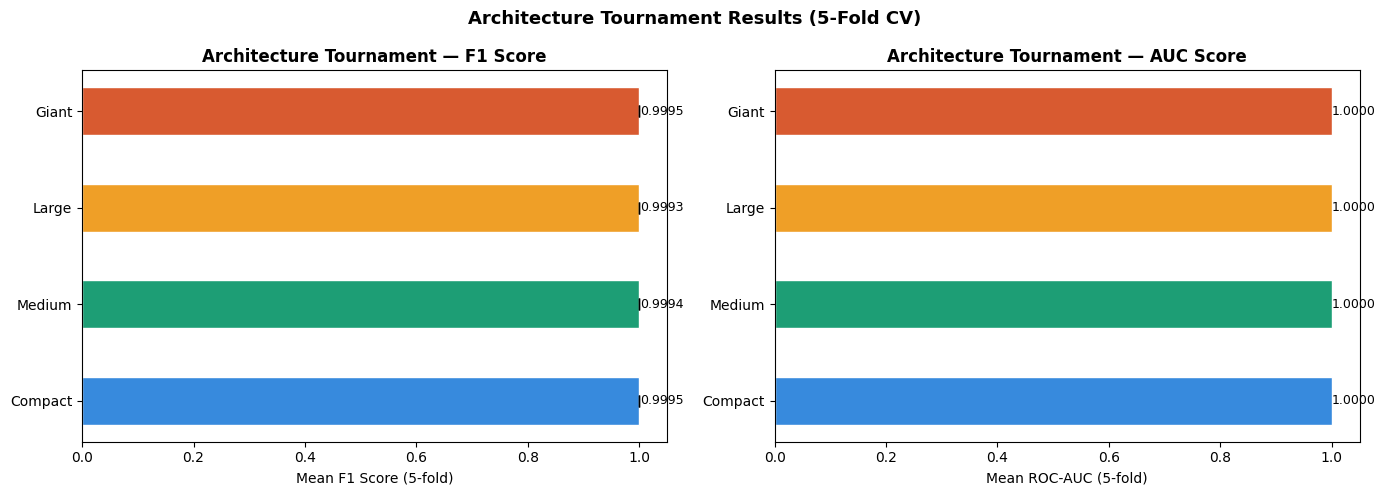

✅ Saved → plot_tournament.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names  = list(tournament_results.keys())
short  = [n.split('—')[1].strip() for n in names]
f1s    = [tournament_results[n]['f1_mean']  for n in names]
aucs   = [tournament_results[n]['auc_mean'] for n in names]
f1_std = [tournament_results[n]['f1_std']   for n in names]

colors = ['#378ADD', '#1D9E75', '#EF9F27', '#D85A30']

axes[0].barh(short, f1s, xerr=f1_std, color=colors,
             edgecolor='white', height=0.5, capsize=4)
axes[0].set_xlabel('Mean F1 Score (5-fold)')
axes[0].set_title('Architecture Tournament — F1 Score',
                  fontweight='bold')
for i, (v, e) in enumerate(zip(f1s, f1_std)):
    axes[0].text(v + e + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

axes[1].barh(short, aucs, color=colors, edgecolor='white', height=0.5)
axes[1].set_xlabel('Mean ROC-AUC (5-fold)')
axes[1].set_title('Architecture Tournament — AUC Score',
                  fontweight='bold')
for i, v in enumerate(aucs):
    axes[1].text(v + 0.0001, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('Architecture Tournament Results (5-Fold CV)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_tournament.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → plot_tournament.png")

In [9]:
print(f"\n\n{'█'*55}")
print(f"  PHASE 3 — DEEP FINAL TRAINING")
print(f"  Winner: {WINNER_NAME}")
print(f"  Layers: {WINNER_LAYERS}")
print(f"  Max epochs   : 500")
print(f"  Learning rate: 0.0001  (10x smaller than tournament)")
print(f"  Batch size   : 256     (2x smaller = more updates/epoch)")
print(f"  LR schedule  : cosine annealing")
print(f"  Expected time: 45-90 minutes")
print(f"{'█'*55}")

# Cosine annealing LR schedule
def cosine_lr(epoch, total=500, lr_max=1e-4, lr_min=1e-7):
    return lr_min + 0.5 * (lr_max - lr_min) * (
        1 + np.cos(np.pi * epoch / total)
    )

# Validation split from full training data
X_tr_final, X_val_final, y_tr_final, y_val_final = train_test_split(
    X_train_scaled, y_train_bal,
    test_size=0.12, random_state=42, stratify=y_train_bal
)

print(f"\n  Final train set : {len(X_tr_final):,} rows")
print(f"  Final val set   : {len(X_val_final):,} rows")
print(f"\n  Building winner architecture...")

final_model = build_model(WINNER_LAYERS, INPUT_DIM,
                           learning_rate=0.0001, dropout=0.3)
final_model.summary()

print(f"\n  Callbacks:")
print(f"    LiveLogger       — epoch by epoch log")
print(f"    EarlyStopping    — patience=30 epochs")
print(f"    ReduceLROnPlateau— factor=0.3, patience=10")
print(f"    LRScheduler      — cosine annealing")
print(f"    ModelCheckpoint  — saves best val_auc")
print(f"\n  Training starts now...")
print(f"  Watch the loss crawl down slowly — that is learning.\n")

PHASE3_START = time.time()

final_callbacks = [
    LiveLogger(f"FINAL — {WINNER_NAME}", 1, 1),
    EarlyStopping(monitor='val_auc', mode='max',
                  patience=30, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=10, min_lr=1e-8, verbose=1),
    LearningRateScheduler(cosine_lr, verbose=0),
    ModelCheckpoint('best_final_model.keras', monitor='val_auc',
                    mode='max', save_best_only=True, verbose=0),
]

final_history = final_model.fit(
    X_tr_final, y_tr_final,
    epochs          = 500,
    batch_size      = 256,
    validation_data = (X_val_final, y_val_final),
    callbacks       = final_callbacks,
    verbose         = 0,
    shuffle         = True,
)

phase3_time = time.time() - PHASE3_START

print(f"\n  PHASE 3 COMPLETE ✅")
print(f"  Time          : {phase3_time/60:.1f} minutes")
print(f"  Epochs ran    : {len(final_history.history['loss'])}")
print(f"  best_final_model.keras saved")



███████████████████████████████████████████████████████
  PHASE 3 — DEEP FINAL TRAINING
  Winner: Arch D — Giant
  Layers: [1024, 512, 256, 128, 64, 32]
  Max epochs   : 500
  Learning rate: 0.0001  (10x smaller than tournament)
  Batch size   : 256     (2x smaller = more updates/epoch)
  LR schedule  : cosine annealing
  Expected time: 45-90 minutes
███████████████████████████████████████████████████████

  Final train set : 73,263 rows
  Final val set   : 9,991 rows

  Building winner architecture...
Model: "sequential_24"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Dense_1 (Dense)             (None, 1024)              40960     
                                                                 
 BN_1 (BatchNormalization)   (None, 1024)              4096      
                                                                 
 ReLU_1 (Activation)         (None, 1024)              0         
     

  NEURAL NETWORK — FINAL TEST RESULTS
  Accuracy  : 99.2560%
  F1 Score  : 0.6609
  ROC-AUC   : 0.9996

              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     10408
      Outage       0.49      1.00      0.66        76

    accuracy                           0.99     10484
   macro avg       0.75      1.00      0.83     10484
weighted avg       1.00      0.99      0.99     10484



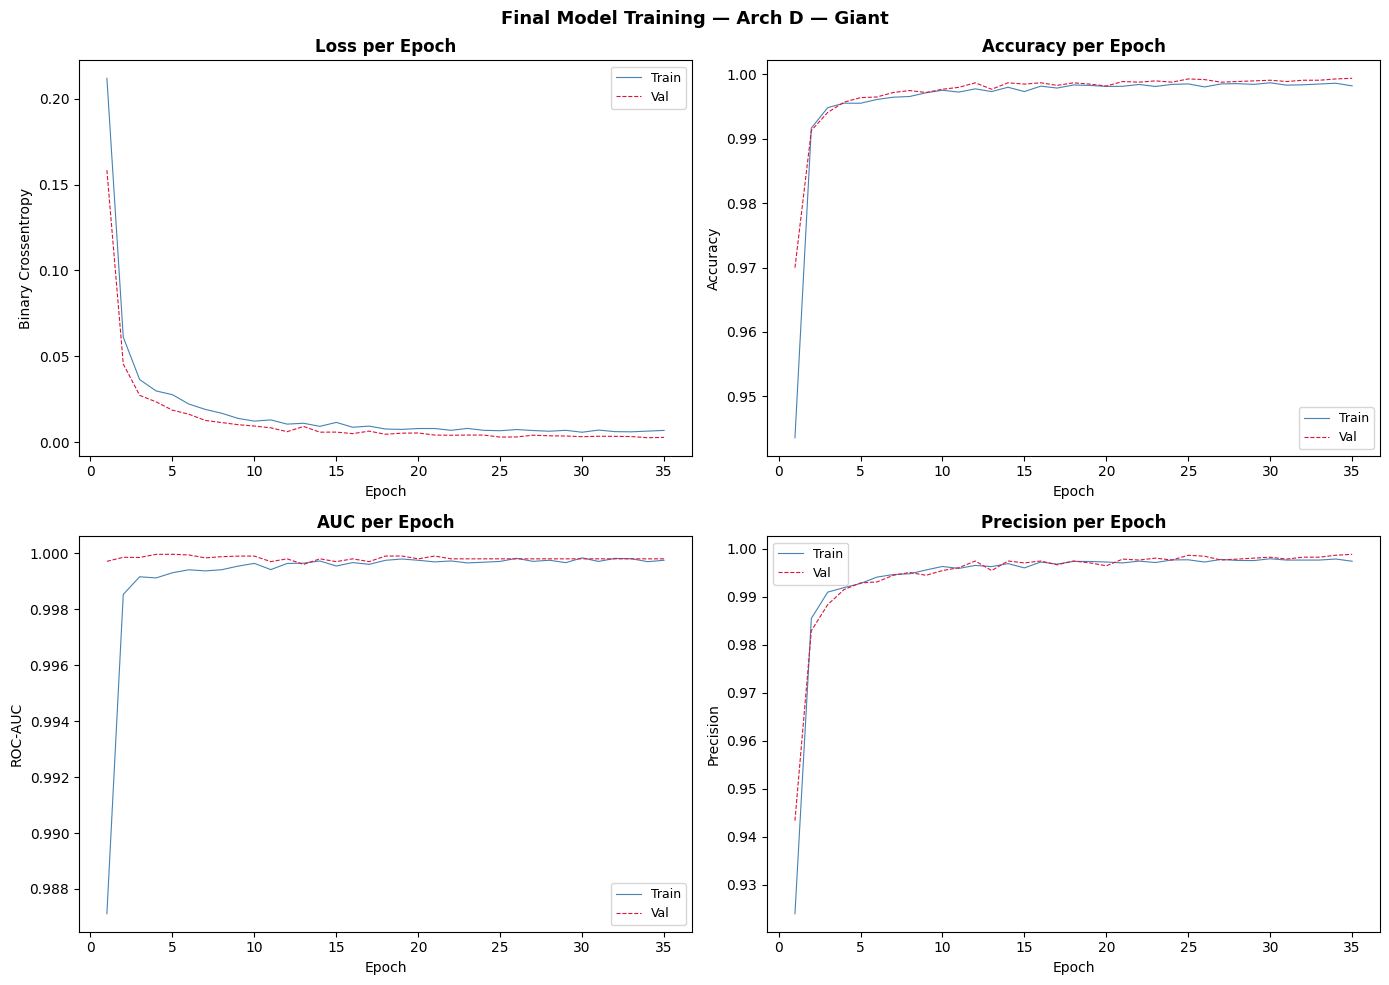

✅ Saved → plot_final_training_curves.png


In [10]:
best_model = keras.models.load_model('best_final_model.keras')

y_prob_nn = best_model.predict(X_test_scaled, verbose=0).flatten()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

f1_nn  = f1_score(y_test, y_pred_nn)
auc_nn = roc_auc_score(y_test, y_prob_nn)
acc_nn = (y_pred_nn == y_test.values).mean()

print("="*55)
print("  NEURAL NETWORK — FINAL TEST RESULTS")
print("="*55)
print(f"  Accuracy  : {acc_nn*100:.4f}%")
print(f"  F1 Score  : {f1_nn:.4f}")
print(f"  ROC-AUC   : {auc_nn:.4f}")
print()
print(classification_report(y_test, y_pred_nn,
                             target_names=['Normal','Outage']))

# Training curves
hist = final_history.history
ep   = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Final Model Training — {WINNER_NAME}',
             fontsize=13, fontweight='bold')

for ax, (tr_k, vl_k, title, ylabel) in zip(axes.flat, [
    ('loss',      'val_loss',      'Loss per Epoch',     'Binary Crossentropy'),
    ('accuracy',  'val_accuracy',  'Accuracy per Epoch', 'Accuracy'),
    ('auc',       'val_auc',       'AUC per Epoch',      'ROC-AUC'),
    ('precision', 'val_precision', 'Precision per Epoch','Precision'),
]):
    ax.plot(ep, hist[tr_k], color='steelblue', linewidth=0.8, label='Train')
    ax.plot(ep, hist[vl_k], color='crimson', linestyle='--',
            linewidth=0.8, label='Val')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('plot_final_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → plot_final_training_curves.png")

In [11]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV

print(f"\n\n{'█'*55}")
print(f"  PHASE 4 — XGBOOST BATTLE")
print(f"  Round 1: RandomizedSearchCV (30 combos × 5 fold)")
print(f"  Round 2: Retrain best config (2000 trees + early stop)")
print(f"  Watch round-by-round logloss drop live")
print(f"{'█'*55}\n")

# ── Round 1: Search ─────────────────────────────────────────
print("  ROUND 1 — Hyperparameter search")
print("  30 combinations × 5-fold = 150 fits")
print("  verbose=2 prints every single fit live\n")

xgb_params = {
    'n_estimators'    : randint(200, 800),
    'max_depth'       : randint(3, 10),
    'learning_rate'   : uniform(0.005, 0.15),
    'subsample'       : uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'min_child_weight': randint(1, 8),
    'gamma'           : uniform(0, 0.4),
    'reg_alpha'       : uniform(0, 0.8),
    'reg_lambda'      : uniform(0.5, 2),
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        eval_metric       = 'logloss',
        use_label_encoder = False,
        random_state      = 42,
        n_jobs            = -1,
        tree_method       = 'hist',
    ),
    param_distributions = xgb_params,
    n_iter              = 30,
    cv                  = 5,
    scoring             = 'f1',
    verbose             = 2,
    random_state        = 42,
    n_jobs              = 1,
    return_train_score  = True,
)

t0 = time.time()
xgb_search.fit(X_train_scaled, y_train_bal)
search_time = time.time() - t0

print(f"\n  ROUND 1 COMPLETE ✅")
print(f"  Time        : {search_time/60:.1f} minutes")
print(f"  Best CV F1  : {xgb_search.best_score_:.4f}")
print(f"  Best params :")
for k, v in xgb_search.best_params_.items():
    print(f"    {k:<22} : {v}")



███████████████████████████████████████████████████████
  PHASE 4 — XGBOOST BATTLE
  Round 1: RandomizedSearchCV (30 combos × 5 fold)
  Round 2: Retrain best config (2000 trees + early stop)
  Watch round-by-round logloss drop live
███████████████████████████████████████████████████████

  ROUND 1 — Hyperparameter search
  30 combinations × 5-fold = 150 fits
  verbose=2 prints every single fit live

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END colsample_bytree=0.6872700594236812, gamma=0.3802857225639665, learning_rate=0.11479909127171077, max_depth=7, min_child_weight=5, n_estimators=321, reg_alpha=0.12479561626896213, reg_lambda=0.6161672243363989, subsample=0.9464704583099741; total time=   1.0s
[CV] END colsample_bytree=0.6872700594236812, gamma=0.3802857225639665, learning_rate=0.11479909127171077, max_depth=7, min_child_weight=5, n_estimators=321, reg_alpha=0.12479561626896213, reg_lambda=0.6161672243363989, subsample=0.9464704583099741; total time=   

In [15]:
from xgboost.callback import TrainingCallback
import numpy as np

print(f"\n  ROUND 2 — Deep retrain with early stopping")
print(f"  2000 tree ceiling — will stop early when val stops improving")
print(f"  Prints every 10 rounds live\n")

X_xgb_tr, X_xgb_val, y_xgb_tr, y_xgb_val = train_test_split(
    X_train_scaled, y_train_bal,
    test_size=0.1, random_state=42, stratify=y_train_bal
)

# ── Remove keys we override manually ───────────────────────
best_p = {k: v for k, v in xgb_search.best_params_.items()}
best_p.pop('n_estimators', None)      # we set this to 2000
best_p.pop('early_stopping_rounds', None)  # we set this to 40

print(f"  Best params from search (overrides removed):")
for k, v in best_p.items():
    print(f"    {k:<22} : {v}")

# ── Detect evals_log key names ──────────────────────────────
print(f"\n  Detecting evals_log key names from your XGBoost version...")

_discovered_keys = {}

class KeyDetector(TrainingCallback):
    def after_iteration(self, model, epoch, evals_log):
        if epoch == 0:
            print(f"  evals_log keys found: {list(evals_log.keys())}")
            for dataset_key, metrics in evals_log.items():
                print(f"    '{dataset_key}' → {list(metrics.keys())}")
            _discovered_keys.update(evals_log)
        return True

_detector = KeyDetector()
_probe = XGBClassifier(
    n_estimators=2, eval_metric='logloss',
    use_label_encoder=False, random_state=42,
    tree_method='hist', verbosity=0,
    callbacks=[_detector]
)
_probe.fit(
    X_xgb_tr, y_xgb_tr,
    eval_set=[(X_xgb_tr, y_xgb_tr), (X_xgb_val, y_xgb_val)],
    verbose=False
)

dataset_keys = list(_discovered_keys.keys())
train_key    = dataset_keys[0]
val_key      = dataset_keys[1]
print(f"\n  Using → train_key: '{train_key}'  |  val_key: '{val_key}'")

# ── Live Logger ─────────────────────────────────────────────
class XGBLiveLogger(TrainingCallback):
    def __init__(self, train_key, val_key):
        super().__init__()
        self.train_key  = train_key
        self.val_key    = val_key
        self.best_val   = np.inf
        self.best_round = 0
        self.rounds     = []
        print(f"\n  {'Round':>6} │ {'Train Logloss':>14} │ "
              f"{'Val Logloss':>12} │ Status")
        print(f"  {'─'*58}")

    def after_iteration(self, model, epoch, evals_log):
        try:
            tr_loss  = evals_log[self.train_key]['logloss'][-1]
            val_loss = evals_log[self.val_key]['logloss'][-1]
        except (KeyError, IndexError):
            tr_loss, val_loss = 0.0, 0.0

        self.rounds.append({'round': epoch, 'tr': tr_loss, 'val': val_loss})

        improved = ''
        if val_loss < self.best_val:
            self.best_val   = val_loss
            self.best_round = epoch
            improved        = '  🔥 best!'

        trend = ''
        if len(self.rounds) > 1:
            trend = '↓' if val_loss <= self.rounds[-2]['val'] else '↑'

        if epoch % 10 == 0 or improved:
            print(f"  {epoch:>6} │ {tr_loss:>14.5f} │ "
                  f"{val_loss:>12.5f} │ {trend}{improved}")
        return False

xgb_logger = XGBLiveLogger(train_key, val_key)

# ── Final XGBoost ───────────────────────────────────────────
final_xgb = XGBClassifier(
    **best_p,                          # search params (n_estimators removed)
    n_estimators          = 2000,      # override with 2000
    eval_metric           = 'logloss',
    use_label_encoder     = False,
    random_state          = 42,
    n_jobs                = -1,
    tree_method           = 'hist',
    early_stopping_rounds = 40,
    verbosity             = 0,
    callbacks             = [xgb_logger],
)

t0 = time.time()
final_xgb.fit(
    X_xgb_tr, y_xgb_tr,
    eval_set = [(X_xgb_tr, y_xgb_tr), (X_xgb_val, y_xgb_val)],
    verbose  = False,
)
xgb_time = time.time() - t0

print(f"\n  {'─'*58}")
print(f"  ROUND 2 COMPLETE ✅")
print(f"  Time             : {xgb_time/60:.1f} minutes")
print(f"  Best iteration   : {final_xgb.best_iteration}")
print(f"  Best val logloss : {xgb_logger.best_val:.5f}")
print(f"  Best round       : {xgb_logger.best_round}")

joblib.dump(final_xgb, 'model_final_xgb.pkl')
print(f"  model_final_xgb.pkl saved ✅")

# ── Evaluate on test ────────────────────────────────────────
y_prob_xgb = final_xgb.predict_proba(X_test_scaled)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)
f1_xgb     = f1_score(y_test, y_pred_xgb)
auc_xgb    = roc_auc_score(y_test, y_prob_xgb)
acc_xgb    = (y_pred_xgb == y_test.values).mean()

print(f"\n  XGBoost final test results:")
print(f"  Accuracy  : {acc_xgb*100:.4f}%")
print(f"  F1 Score  : {f1_xgb:.4f}")
print(f"  ROC-AUC   : {auc_xgb:.4f}")
print()
print(classification_report(y_test, y_pred_xgb,
                             target_names=['Normal', 'Outage']))


  ROUND 2 — Deep retrain with early stopping
  2000 tree ceiling — will stop early when val stops improving
  Prints every 10 rounds live

  Best params from search (overrides removed):
    colsample_bytree       : 0.864803089169032
    gamma                  : 0.25502298854208527
    learning_rate          : 0.13808191138644899
    max_depth              : 3
    min_child_weight       : 3
    reg_alpha              : 0.6791310594128671
    reg_lambda             : 1.9434590423297464
    subsample              : 0.6943939678995823

  Detecting evals_log key names from your XGBoost version...
  evals_log keys found: ['validation_0', 'validation_1']
    'validation_0' → ['logloss']
    'validation_1' → ['logloss']

  Using → train_key: 'validation_0'  |  val_key: 'validation_1'

   Round │  Train Logloss │  Val Logloss │ Status
  ──────────────────────────────────────────────────────────
       0 │        0.56472 │      0.56469 │   🔥 best!
       1 │        0.46718 │      0.46717 │ ↓  🔥

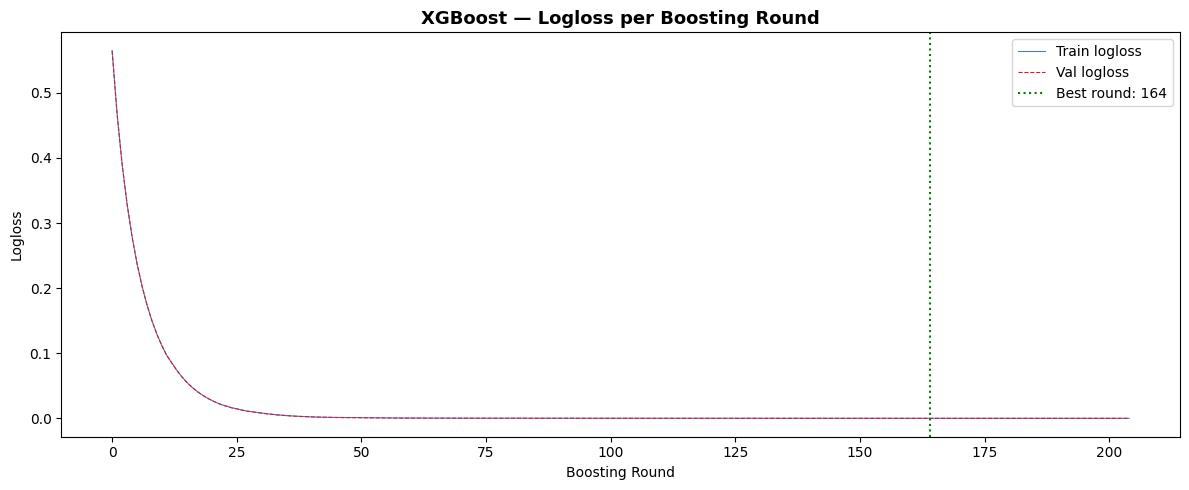

✅ Saved → plot_xgb_rounds.png


In [16]:
rounds_df = pd.DataFrame(xgb_logger.rounds)

plt.figure(figsize=(12, 5))
plt.plot(rounds_df['round'], rounds_df['tr'],  label='Train logloss',
         color='steelblue', linewidth=0.8)
plt.plot(rounds_df['round'], rounds_df['val'], label='Val logloss',
         color='crimson', linewidth=0.8, linestyle='--')
plt.axvline(x=final_xgb.best_iteration, color='green',
            linestyle=':', linewidth=1.5,
            label=f'Best round: {final_xgb.best_iteration}')
plt.xlabel('Boosting Round')
plt.ylabel('Logloss')
plt.title('XGBoost — Logloss per Boosting Round',
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('plot_xgb_rounds.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → plot_xgb_rounds.png")



████████████████████████████████████████████████████████████
  GRAND FINAL LEADERBOARD — NN vs XGBoost
████████████████████████████████████████████████████████████

  Model                            │  Accuracy │      F1 │     AUC
  ────────────────────────────────────────────────────────────
  XGBoost (Tuned + Early Stop)     │  99.9809% │  0.9870 │  1.0000
  Neural Network (Deep Final)      │  99.2560% │  0.6609 │  0.9996

  🥇 CHAMPION : XGBoost (Tuned + Early Stop)
     F1       : 0.9870
     AUC      : 1.0000


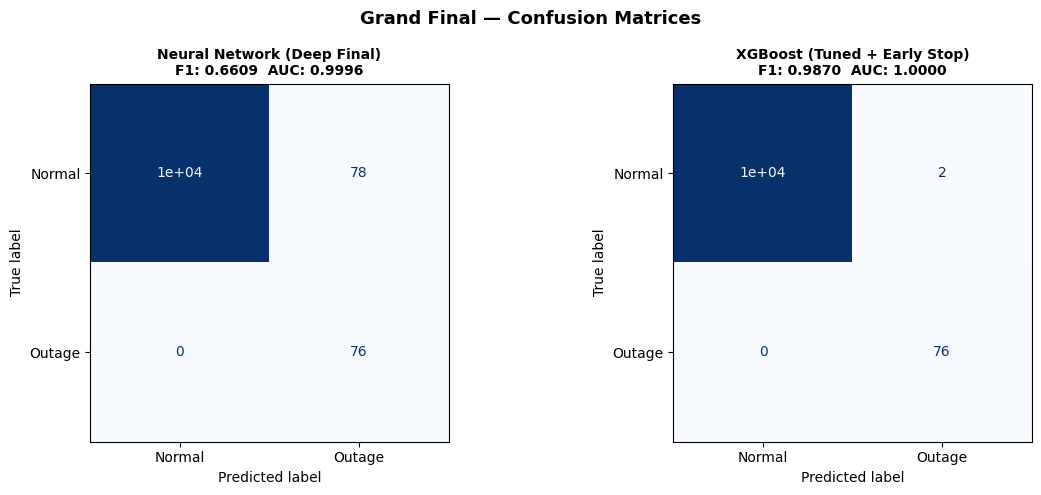

  Champion saved → model_champion.pkl ✅

  champion_results.pkl saved ✅


In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

print("\n\n" + "█"*60)
print("  GRAND FINAL LEADERBOARD — NN vs XGBoost")
print("█"*60)

models_final = {
    'Neural Network (Deep Final)': {
        'y_pred': y_pred_nn, 'y_prob': y_prob_nn,
        'f1': f1_nn, 'auc': auc_nn, 'acc': acc_nn
    },
    'XGBoost (Tuned + Early Stop)': {
        'y_pred': y_pred_xgb, 'y_prob': y_prob_xgb,
        'f1': f1_xgb, 'auc': auc_xgb, 'acc': acc_xgb
    },
}

print(f"\n  {'Model':<32} │ {'Accuracy':>9} │ {'F1':>7} │ {'AUC':>7}")
print(f"  {'─'*60}")
for name, r in sorted(models_final.items(),
                       key=lambda x: x[1]['f1'], reverse=True):
    print(f"  {name:<32} │ {r['acc']*100:>8.4f}% │ "
          f"{r['f1']:>7.4f} │ {r['auc']:>7.4f}")

winner = max(models_final, key=lambda k: models_final[k]['f1'])
print(f"\n  🥇 CHAMPION : {winner}")
print(f"     F1       : {models_final[winner]['f1']:.4f}")
print(f"     AUC      : {models_final[winner]['auc']:.4f}")

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, r) in zip(axes, models_final.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Normal','Outage']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f"{name}\nF1: {r['f1']:.4f}  AUC: {r['auc']:.4f}",
                 fontsize=10, fontweight='bold')

plt.suptitle('Grand Final — Confusion Matrices',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_grand_final.png', dpi=150, bbox_inches='tight')
plt.show()

# Save champion
champ_model = best_model if 'Neural' in winner else final_xgb
if 'Neural' in winner:
    best_model.save('model_champion.keras')
    print("  Champion saved → model_champion.keras ✅")
else:
    joblib.dump(final_xgb, 'model_champion.pkl')
    print("  Champion saved → model_champion.pkl ✅")
joblib.dump({'winner': winner, 'results': models_final}, 'champion_results.pkl')
print("\n  champion_results.pkl saved ✅")

In [18]:
total_time = time.time() - TOURNAMENT_START

print("\n" + "█"*60)
print("  COMPLETE SESSION SUMMARY")
print("█"*60)
print(f"\n  Phase 1 — Data hardening")
print(f"    Features added     : 9 interaction features")
print(f"    Noise injected     : 2% Gaussian on all features")
print(f"    Labels flipped     : 1% for robustness")
print(f"\n  Phase 2 — Architecture tournament")
print(f"    Architectures tried: {len(ARCHITECTURES)}")
print(f"    Folds per arch     : 5")
print(f"    Total training runs: {len(ARCHITECTURES)*5}")
print(f"    Winner             : {WINNER_NAME}")
print(f"\n  Phase 3 — Deep final training")
print(f"    Max epochs         : 500")
print(f"    Learning rate      : 0.0001 (cosine annealing)")
print(f"    Epochs actually ran: {len(final_history.history['loss'])}")
print(f"\n  Phase 4 — XGBoost battle")
print(f"    Search combos      : 30 × 5-fold = 150 fits")
print(f"    Trees ceiling      : 2000")
print(f"    Best iteration     : {final_xgb.best_iteration}")
print(f"\n  Champion model     : {winner}")
print(f"  Champion F1        : {models_final[winner]['f1']:.4f}")
print(f"  Champion AUC       : {models_final[winner]['auc']:.4f}")
print(f"\n  Files saved:")
print(f"    best_final_model.keras")
print(f"    model_final_xgb.pkl")
print(f"    scaler_hard.pkl")
print(f"    champion_results.pkl")
print(f"    plot_tournament.png")
print(f"    plot_final_training_curves.png")
print(f"    plot_xgb_rounds.png")
print(f"    plot_grand_final.png")
print(f"\n  ✅ Day 3 fully complete!")
print(f"     Move to Day 4 — Isolation Forest + Streamlit Dashboard")


████████████████████████████████████████████████████████████
  COMPLETE SESSION SUMMARY
████████████████████████████████████████████████████████████

  Phase 1 — Data hardening
    Features added     : 9 interaction features
    Noise injected     : 2% Gaussian on all features
    Labels flipped     : 1% for robustness

  Phase 2 — Architecture tournament
    Architectures tried: 4
    Folds per arch     : 5
    Total training runs: 20
    Winner             : Arch D — Giant

  Phase 3 — Deep final training
    Max epochs         : 500
    Learning rate      : 0.0001 (cosine annealing)
    Epochs actually ran: 35

  Phase 4 — XGBoost battle
    Search combos      : 30 × 5-fold = 150 fits
    Trees ceiling      : 2000
    Best iteration     : 164

  Champion model     : XGBoost (Tuned + Early Stop)
  Champion F1        : 0.9870
  Champion AUC       : 1.0000

  Files saved:
    best_final_model.keras
    model_final_xgb.pkl
    scaler_hard.pkl
    champion_results.pkl
    plot_tournamen

In [7]:
import joblib
from xgboost import XGBClassifier
from xgboost.callback import TrainingCallback
import numpy as np

# ── Step 1: Redefine the class so pickle can find it ────────
class XGBLiveLogger(TrainingCallback):
    def __init__(self, train_key='validation_0', val_key='validation_1'):
        super().__init__()
        self.train_key  = train_key
        self.val_key    = val_key
        self.best_val   = np.inf
        self.best_round = 0
        self.rounds     = []

    def after_iteration(self, model, epoch, evals_log):
        try:
            tr_loss  = evals_log[self.train_key]['logloss'][-1]
            val_loss = evals_log[self.val_key]['logloss'][-1]
        except (KeyError, IndexError):
            tr_loss, val_loss = 0.0, 0.0
        self.rounds.append({'round': epoch, 'tr': tr_loss, 'val': val_loss})
        if val_loss < self.best_val:
            self.best_val   = val_loss
            self.best_round = epoch
        return False

# ── Step 2: Now load the pkl (class exists in memory now) ───
print("Loading model_final_xgb.pkl...")
original = joblib.load('model_final_xgb.pkl')
print(f"✅ Loaded! Type: {type(original)}")

# ── Step 3: Save as native JSON immediately ─────────────────
print("\nSaving as xgb_model_native.json...")
original.get_booster().save_model('xgb_model_native.json')
print("✅ Saved → xgb_model_native.json")

# ── Step 4: Verify it loads cleanly with no dependencies ────
print("\nVerifying clean load...")
clean_xgb = XGBClassifier()
clean_xgb.load_model('xgb_model_native.json')
print("✅ Clean load successful — no class dependencies!")
print("   Ready to use in app.py")

Loading model_final_xgb.pkl...
✅ Loaded! Type: <class 'xgboost.sklearn.XGBClassifier'>

Saving as xgb_model_native.json...
✅ Saved → xgb_model_native.json

Verifying clean load...
✅ Clean load successful — no class dependencies!
   Ready to use in app.py


C:\Users\parit\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:158: UserWarning: [16:17:21] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\data\../common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)
